In [1]:
import sys
import time
from dataclasses import replace
from pathlib import Path

import numpy as np

ROOT = Path.cwd()
if not (ROOT / "eos").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

from eos import alphabag, ccdm, njl, vmit
from eos.ccdm.table import rows_from_result as ccdm_rows_from_result
from eos.general.figure_style import (LABELS, OKAB_CAT, log_decades,
                                      panel_label, paper_grid,
                                      particle_style)
from eos.general.physics_constants import hc3
from eos.general.table_io import matrix_from_rows
from eos.ccdm.couplings import vector_coupling
from scipy.optimize import root

from eos.ccdm.thermodynamics import (dielectric, glue_potential,
                                     state_at, thermo_from_mu)
from eos.njl import vector_self_energy
from eos.njl.table import rows_from_result as njl_rows_from_result

# Name -> package. Every model exposes the same entry points under the same
# names — `Parameters`, `SpeciesFlags`, `eos_point`, `eos_table` — so one loop
# body serves all four. `rows_from_result` is the one that is not uniform:
# `vmit` and `alphabag` re-export it from the package, `njl` and `ccdm` leave it
# in their `table` module, so it is looked up here once rather than branched on
# inside the loop.
MODELS = {"vmit": vmit, "alphabag": alphabag, "njl": njl, "ccdm": ccdm}

# The two that carry a `backends/`, and so accept `backend='fast'`.
BACKEND_MODELS = {"njl": njl, "ccdm": ccdm}
ROWS_FROM_RESULT = {"vmit": vmit.rows_from_result,
                    "alphabag": alphabag.rows_from_result,
                    "njl": njl_rows_from_result,
                    "ccdm": ccdm_rows_from_result}

## One T = 0 beta-equilibrium line, per model

The quark counterpart of `hadronic_timing`: four models of deconfined matter
driven through the same public entry points, in the same mode, on the same
density grid, and timed the same way.

The sectors are the six names of CLAUDE.md section 4, spelled identically in
every model, plus `csc` — the pairing sector, which exists only where the
functional has it. `vmit` and `alphabag` carry no such field, so passing it
would be a `TypeError`, which is this notebook's own bug and not a model
refusing anything; the flag is therefore added per model rather than shared.

`muons` is off for all four, and that is a gap rather than a choice: `njl` and
`ccdm` wire the muon family, `vmit` and `alphabag` do not and raise if asked.
One shared value is what keeps all four models in the same figures.

In [2]:
# The six section-4 names, identical in every model.
SPECIES = dict(hyperons=False, deltas=False, muons=False,
               thermal_mesons=False, thermal_neutrinos=False, photons=False)

# `csc` only where the pairing sector is in the functional. False everywhere:
# this notebook is unpaired quark matter.
CSC = {"njl": False, "ccdm": False}

# The published set each model is driven at; None = Parameters.default().
#   vmit, alphabag  ship exactly one set each, so there is nothing to name.
#   njl             "rkh" is the shipped default — the set every verified number
#                   in the model's documentation was produced at and the one
#                   test/baseline is frozen at.
#   ccdm            "baseline" is the specification's own baseline set, likewise
#                   the shipped default. Its deconfinement onset sits just below
#                   1 fm^-3, well inside the grid below, which is the point:
#                   the densities underneath it come back unsolved and that is
#                   physics about the model, not a solver failure.
PARAMETER_SET = {"vmit": None, "alphabag": None,
                 "njl": "rkh", "ccdm": "baseline"}

# 0.1 to 1.6 fm^-3. The top is a few times saturation, which is where a hybrid
# star's quark core lives; the bottom is deliberately below any of these phases
# being the physical state, so `ccdm`'s onset shows up as refusals in the count
# rather than being hidden by a grid chosen to flatter it.
N_B = np.linspace(0.1, 1.6, 60)
T = 0.0

TABLES = {}          # {model: rows}, read by every figure below
PARAMS = {}          # {model: par}, read by the effective-mass figure

print(f"=== one line, beta_eq_neutrinoless, T = {T} MeV, "
      f"{len(N_B)} points from {N_B[0]:.3f} to {N_B[-1]:.3f} fm^-3 ===")

for name, module in MODELS.items():
    published = PARAMETER_SET[name]
    par = (module.Parameters.default() if published is None
           else module.Parameters.named(published))

    # A model that does not have one of the selected sectors refuses — at flag
    # construction where the sector is absent from the functional, inside
    # `eos_point` where the mode is not one this phase has. Both are the
    # library's contract working, so they are printed and skipped, never dressed
    # up as a result. `TypeError` is deliberately not caught: an unexpected
    # keyword is this notebook's own bug.
    # `backend` exists only where the model HAS a second flavour of its
    # integrals: `njl` and `ccdm` carry a `backends/`, the two bag models do
    # not and would raise TypeError. Added per model for the same reason `csc`
    # is, rather than passed to all four.
    fast = {"backend": "fast"} if name in BACKEND_MODELS else {}

    try:
        species = module.SpeciesFlags(
            **SPECIES, **({"csc": CSC[name]} if name in CSC else {}))

        # The first 'fast' call in a session pays numba's compile time, so
        # the jitted models run once untimed. Without this the compile lands
        # on the "first point" number and reads as a slow model.
        if fast:
            module.eos_point(par, "beta_eq_neutrinoless", species,
                             n_B=float(N_B[0]), T=T, **fast)

        start = time.perf_counter()
        point = module.eos_point(par, "beta_eq_neutrinoless", species,
                                 n_B=float(N_B[0]), T=T, **fast)
        first_s = time.perf_counter() - start

        start = time.perf_counter()
        table = module.eos_table(par, "beta_eq_neutrinoless", species,
                                 {"nB": N_B, "T": np.array([T])}, **fast)
        line_s = time.perf_counter() - start
    except (NotImplementedError, ValueError) as err:
        print(f"  [{name}] not supported: {err}")
        continue

    rows = ROWS_FROM_RESULT[name](table)
    TABLES[name] = rows
    PARAMS[name] = par

    # Non-convergence is a return value, not an exception: it is found by
    # testing `.ok`, which no `except` clause would ever see. Unlike the
    # hadronic notebook this does NOT drop the model — the first density of this
    # grid is below `ccdm`'s deconfinement onset, so a failure there is a
    # statement about where the phase begins and the rest of the line is still
    # a result.
    note = "" if point.ok else f"   [first point: {point.message}]"
    print(f"  [{name:9s} {published or 'default':9s}] "
          f"first point {1e3 * first_s:8.2f} ms   "
          f"line {line_s:7.3f} s   "
          f"{1e3 * line_s / max(len(rows), 1):7.2f} ms/pt   "
          f"{len(rows)}/{len(N_B)} points{note}")

=== one line, beta_eq_neutrinoless, T = 0.0 MeV, 60 points from 0.100 to 1.600 fm^-3 ===
  [vmit      default  ] first point   176.74 ms   line   0.010 s      0.16 ms/pt   60/60 points
  [alphabag  default  ] first point     0.14 ms   line   0.006 s      0.10 ms/pt   60/60 points
  [njl       rkh      ] first point     1.81 ms   line   0.083 s      1.39 ms/pt   60/60 points
  [ccdm      baseline ] first point    71.40 ms   line   1.933 s     77.31 ms/pt   25/60 points   [first point: residual 7.329e-01 above the gate at n_B=0.1 fm^-3; below the deconfinement onset this model has no deconfined root at fixed density]


### The two backends, on the same line

`njl` and `ccdm` carry the reference/fast split of CLAUDE.md section 9: the
reference flavour is plain NumPy and is what correctness is judged against,
and `backend='fast'` is the jitted kernel of the model's own `backends/`
(each model has its own — `ccdm`'s recomputes an integration ceiling per
mode, which `njl`'s cut theory has no notion of) plus the compiled pairing
pass of `eos.general.pairing`.

The default is `'reference'` everywhere, so a table is the same table it has
always been and `test/baseline` keeps measuring the path it is frozen
against. The two agree to round-off rather than bit for bit, because they
sum the nine modes in different orders — which is why this cell reports the
largest relative column difference beside the speedup rather than asserting
equality. The first `'fast'` call in a session pays numba's compile time, so
each backend runs once untimed before the clock starts.

In [3]:
print(f"=== reference vs fast, beta_eq_neutrinoless, T = {T} MeV, "
      f"{len(N_B)} points ===")

for name, module in BACKEND_MODELS.items():
    par = module.Parameters.named(PARAMETER_SET[name])
    species = module.SpeciesFlags(**SPECIES, csc=CSC[name])
    axes = {"nB": N_B, "T": np.array([T])}

    timing, tables = {}, {}
    for backend in ("reference", "fast"):
        module.eos_table(par, "beta_eq_neutrinoless", species, axes,
                         backend=backend)          # warm up: compile, not time
        start = time.perf_counter()
        tables[backend] = module.eos_table(par, "beta_eq_neutrinoless",
                                           species, axes, backend=backend)
        timing[backend] = time.perf_counter() - start

    solved = {b: ROWS_FROM_RESULT[name](t) for b, t in tables.items()}
    n_solved = len(solved["reference"])

    # The largest relative difference over every numeric column, skipping the
    # ones that are identically zero: Y_C and Y_e vanish in a CFL phase, so a
    # ratio of one round-off to another there is a cancellation and not a
    # disagreement between the two flavours.
    worst, worst_key = 0.0, ""
    for row_ref, row_fast in zip(solved["reference"], solved["fast"]):
        for key, value in row_ref.items():
            other = row_fast[key]
            if not isinstance(value, float) or value != value:
                continue
            if max(abs(value), abs(other)) < 1.0e-10:
                continue
            relative = abs(value - other) / max(abs(value), abs(other))
            if relative > worst:
                worst, worst_key = relative, key

    per_point = {b: 1e3 * s / max(n_solved, 1) for b, s in timing.items()}
    print(f"  [{name:5s}] reference {per_point['reference']:8.2f} ms/pt   "
          f"fast {per_point['fast']:8.2f} ms/pt   "
          f"{per_point['reference'] / per_point['fast']:5.2f}x   "
          f"{n_solved}/{len(N_B)} points   "
          f"worst column {worst_key or '-'} {worst:.1e}")

=== reference vs fast, beta_eq_neutrinoless, T = 0.0 MeV, 60 points ===
  [njl  ] reference     6.40 ms/pt   fast     1.98 ms/pt    3.23x   60/60 points   worst column Y_C 7.8e-12
  [ccdm ] reference   413.10 ms/pt   fast    77.53 ms/pt    5.33x   25/60 points   worst column Y_C 4.7e-12


### The paired enumeration, full against restricted

With `csc=True` every point solves several candidates and keeps the lowest
free energy. The asymmetric `free` seed exists to let a CFL-layout solve
fall to a state that is not CFL (a uSC/dSC-like state); where no such state
exists it burns its whole retry ladder discovering so — measured at 90% of
one njl point's cost. `patterns=("unpaired", "2SC", "CFL")` is the
documented fast restriction: an explicit declaration that those states are
not being hunted, made by the caller rather than by a default.

A tiny grid, because even restricted, a paired point diagonalises the BdG
problem at every quadrature node of every residual evaluation.

In [ ]:
PAIRED_N_B = {"njl": np.linspace(1.3, 1.6, 4), "ccdm": np.linspace(1.4, 1.7, 4)}
SIMPLE_CSC = ("unpaired", "2SC", "CFL")

print(f"=== csc=True, beta_eq_neutrinoless, T = {T} MeV, backend='fast' ===")
for name, module in BACKEND_MODELS.items():
    par = module.Parameters.named(PARAMETER_SET[name])
    species = module.SpeciesFlags(**SPECIES, csc=True)
    axes = {"nB": PAIRED_N_B[name], "T": np.array([T])}

    timing = {}
    for label, restriction in (("full", None), ("restricted", SIMPLE_CSC)):
        kwargs = {} if restriction is None else {"patterns": restriction}
        module.eos_table(par, "beta_eq_neutrinoless", species, axes,
                         backend="fast", **kwargs)       # warm up, not timed
        start = time.perf_counter()
        table = module.eos_table(par, "beta_eq_neutrinoless", species, axes,
                                 backend="fast", **kwargs)
        timing[label] = time.perf_counter() - start
        n_solved = len(ROWS_FROM_RESULT[name](table))

    n_pts = max(n_solved, 1)
    print(f"  [{name:5s}] full enumeration {1e3 * timing['full'] / n_pts:9.1f}"
          f" ms/pt   ('unpaired','2SC','CFL') "
          f"{1e3 * timing['restricted'] / n_pts:9.1f} ms/pt   "
          f"{timing['full'] / timing['restricted']:5.2f}x")

=== csc=True, beta_eq_neutrinoless, T = 0.0 MeV, backend='fast' ===


### From rows to arrays

`rows_from_result` gives the long format — a plain list of dicts, one per
**converged** point, with the same column names in every model.
`matrix_from_rows` lays those rows back on the grid they were asked for and
returns `({name: array[i_temp, i_nB]}, axes)`, so `matrix["P"][0]` is the whole
T = 0 isotherm.

The axes are left to default here rather than passed in. The solved densities
come back carrying float noise off the requested grid — `njl` returns
0.10000000000000006 where `np.linspace` gave 0.1 — and `matrix_from_rows`
matches exactly and raises rather than dropping a row that is not on the axes
it was handed. Defaulting takes the densities the rows actually carry, which
for one temperature and one line is what a curve is. The trade is that a
refused density is absent instead of nan, which is exactly what the counts
printed above already report.

In [ ]:
MATRIX = {}
for name, rows in TABLES.items():
    matrix, axes = matrix_from_rows(rows)
    MATRIX[name] = (matrix, axes["nB"])
    print(f"  [{name:9s}] {len(axes['nB'])} densities, "
          f"{axes['nB'][0]:.3f} -> {axes['nB'][-1]:.3f} fm^-3   "
          f"columns: {len(matrix)}")

  [vmit     ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 17
  [alphabag ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 17
  [njl      ] 60 densities, 0.100 -> 1.600 fm^-3   columns: 27
  [ccdm     ] 25 densities, 0.990 -> 1.600 fm^-3   columns: 34


### Pressure

One curve per model, colour from `OKAB_CAT`. Linear in both axes: over 0.1 to
1.6 fm^-3 the pressure spans zero to several hundred MeV/fm^3 and passes
through zero on the way, which a log axis cannot draw. Where a curve starts
well inside the panel, that model has no deconfined phase below the density it
starts at.

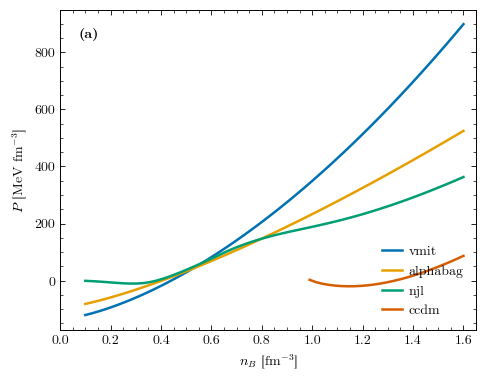

In [ ]:
fig, axes = paper_grid("1x1", mode="centered", placeholder=False, aspect=1.3)
ax = axes.ravel()[0]

for (name, (matrix, n_B)), colour in zip(MATRIX.items(), OKAB_CAT):
    ax.plot(n_B, matrix["P"][0], color=colour, label=name)

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["P"])
ax.set_xlim(0.0, 1.65)
ax.legend(loc="lower right")
panel_label(ax, "(a)")

plt.show()

### Composition

The flavour fractions and the leptons, all four models on one panel. Colour is
the SPECIES and comes from `particle_style` — u blue, d orange, s green,
electrons grey — and linestyle is the MODEL, so the two legends name four
things each instead of one legend naming sixteen. `particle_style` also
returns a linestyle, the one that marks a multiplet in a hadronic composition
figure; here the multiplet is the same for every curve and the linestyle is
needed to say which functional produced it, so only the colour is taken.

Y_e is the one that separates these models: it is the electron fraction beta
equilibrium needs to neutralize whatever charge the flavour composition leaves
over, so a phase that sits close to Y_u = Y_d = Y_s barely needs electrons at
all and one far from it needs many. Muons would appear here as a `Y_mu-`
column in `njl` and `ccdm`; the flag is off (above), so the column is zero and
is dropped by the same threshold that drops any other empty curve.

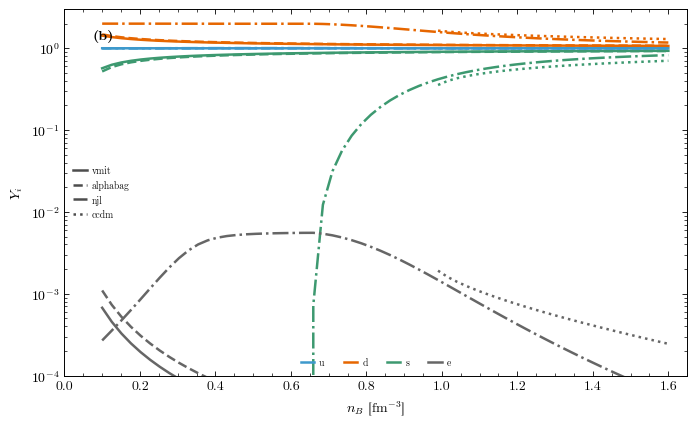

In [ ]:
# Linestyle is the model. Four of them, so the legend that names the models is
# read off this dict rather than from the curves.
MODEL_STYLE = {"vmit": "-", "alphabag": "--", "njl": "-.", "ccdm": ":"}

# The row column name -> the species name `particle_style` knows.
FRACTIONS = {"Y_u": "u", "Y_d": "d", "Y_s": "s",
             "Y_e": "e", "Y_mu-": "mu-"}

# Full page width: sixteen curves and two legends do not fit a single column.
fig, axes = paper_grid("1x1", mode="double", placeholder=False, aspect=1.7)
ax = axes.ravel()[0]

for name, (matrix, n_B) in MATRIX.items():
    for column, species_name in FRACTIONS.items():
        if column not in matrix:
            continue
        fraction = matrix[column][0]
        if np.nanmax(fraction) < 1e-4:      # below the panel, not worth a colour
            continue
        colour, _ = particle_style(species_name)
        ax.plot(n_B, fraction, color=colour, ls=MODEL_STYLE[name])

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["Y_i"])
ax.set_xlim(0.0, 1.65)
ax.set_yscale("log")
ax.set_ylim(1e-4, 3.0)
# CMU Serif has no U+2212, so matplotlib's own mathtext log labels come out as
# hollow boxes below 1. `log_decades` is figure_style's protection for exactly
# that axis and is never removed (CLAUDE.md section 10).
log_decades(ax, axis="y")

# Two legends, built from proxy lines: one says which colour is which species,
# the other which linestyle is which model.
species_keys = [plt.Line2D([], [], color=particle_style(s)[0], label=s)
                for s in ("u", "d", "s", "e")]
model_keys = [plt.Line2D([], [], color="0.3", ls=style, label=name)
              for name, style in MODEL_STYLE.items() if name in MATRIX]
ax.add_artist(ax.legend(handles=species_keys, loc="lower center", ncol=4,
                        fontsize="x-small"))
ax.legend(handles=model_keys, loc="center left", fontsize="x-small")
panel_label(ax, "(b)")

plt.show()

### Effective quark masses

The same colour-is-species, linestyle-is-model reading, and the panel shows two
genuinely different things rather than one quantity computed four ways.

* **`njl` and `ccdm` return a mass.** Their constituent masses come out of a
  gap equation solved at every point, so `M_u`, `M_d`, `M_s` are columns of the
  table and fall with density as chiral symmetry is restored. That falling
  curve is most of what those two models cost — it is why their per-point
  timings above are tens to hundreds of times the bag models'.
* **`vmit` and `alphabag` return no mass column at all.** They have no gap
  equation: the quark masses are current masses carried on the parameter
  object and are the same number at every density. What is drawn for them is
  therefore `par.m_u`, `par.m_d`, `par.m_s`, read from the parameters, and the
  flat lines are shown rather than omitted because a flat line IS the physical
  statement — alphaBag's u and d sit at exactly zero and are off the bottom of
  a log axis, which is the same statement again.

The two are not interchangeable and the panel does not pretend they are: one
set of curves is a solved quantity and the other is an input.

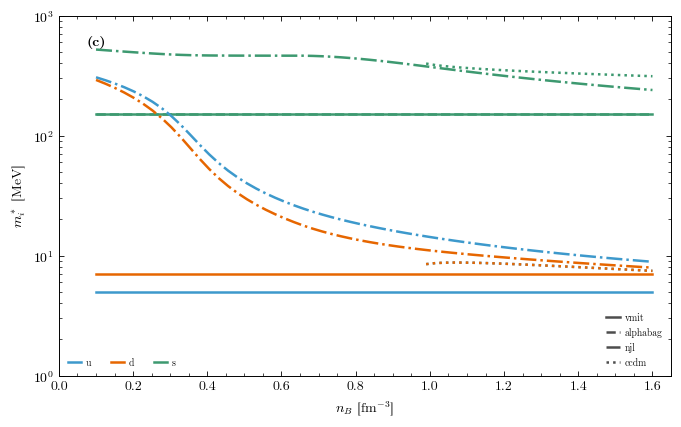

In [ ]:
fig, axes = paper_grid("1x1", mode="double", placeholder=False, aspect=1.7)
ax = axes.ravel()[0]

for name, (matrix, n_B) in MATRIX.items():
    for flavour in ("u", "d", "s"):
        column = f"M_{flavour}"
        if column in matrix:
            mass = matrix[column][0]                 # solved: the gap equation
        else:
            # No gap equation in this functional; the mass is the parameter.
            mass = np.full(n_B.shape,
                           getattr(PARAMS[name], f"m_{flavour}"))
        colour, _ = particle_style(flavour)
        ax.plot(n_B, mass, color=colour, ls=MODEL_STYLE[name])

ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$m^*_i$ [MeV]")
ax.set_xlim(0.0, 1.65)
ax.set_yscale("log")
ax.set_ylim(1.0, 1e3)
log_decades(ax, axis="y")

flavour_keys = [plt.Line2D([], [], color=particle_style(f)[0], label=f)
                for f in ("u", "d", "s")]
ax.add_artist(ax.legend(handles=flavour_keys, loc="lower left", ncol=3,
                        fontsize="x-small"))
ax.legend(handles=model_keys, loc="lower right", fontsize="x-small")
panel_label(ax, "(c)")

plt.show()

## The njl parametrizations, side by side

`eos.njl.PUBLISHED_SETS` ships three, and at `csc=False` they are **not**
three independent points: the diquark coupling `eta_D` only enters the
pairing sector, so with the gaps off `kunkel` differs from `rkh` by its
vector coupling and by nothing else. What separates the three here is
therefore one sector — how the model carries vector repulsion:

* **rkh** — the RKH vacuum fit (Rehberg, Klevansky, Huefner, PRC 53, 410),
  `eta_V = 0`: no vector repulsion at all. `Sigma_V` is identically zero.
* **kunkel** — `eta_D = 1.45, eta_V = 0.7`, the constant-coupling form, so
  `Sigma_V` grows linearly with quark density. `eta_D` is inert at
  `csc=False`; it is what makes this set a strong-coupling point once
  `csc=True`.
* **gluon_exchange** — `G_V = G_V0/[1 + 8 k_F^2/(9 M_g^2)]`, a coupling that
  is a FUNCTION of the state, so `Sigma_V` saturates instead of running away.

The tier-1 vacuum numbers (Lambda, G_S Lambda^2, K Lambda^5, the current
masses) are the same in all three, so the vacuum masses and the whole chiral
sector start identical and separate only where the density does.

NJL has no meson mean fields — it is a contact interaction, and the only
field-like quantity it carries is `Sigma_V`, the vector self-energy that
shifts `mu*_j = mu_j - Sigma_V`. The condensates phi_f are the model's other
"field", and they are the constituent masses of the mass figure restated,
since `M_f = m_f - 4 G_S phi_f + 2 K phi_g phi_h`.

Colour is the SET in every figure, because comparing parametrizations is what
these are for; the species or field is the linestyle.

**The mass and composition figures come out degenerate, and that is the
result.** At fixed n_B in beta equilibrium the three sets agree on the
constituent masses, on every Y_i and on mu_C to 1e-14, and disagree on P, eps
and mu_B. Sigma_V is FLAVOUR-BLIND -- it shifts every mode by the same
amount -- so it cancels out of mu_C = mu_d - mu_u, which is what beta
equilibrium and neutrality close the composition with; and the condensates
that set M_f are functions of the densities, which the density axis has
already fixed. A vector coupling in this model buys stiffness and nothing
else, which is exactly why it is the knob a hybrid-star study turns.

In [ ]:
NJL_SETS = ("rkh", "kunkel", "gluon_exchange")
NJL_NB = np.linspace(0.2, 1.8, 80)      # above the chiral transition, into the
                                        # density a hybrid star's core reaches
NJL_FLAGS = njl.SpeciesFlags(csc=False)  # unpaired: no gaps, so eta_D is inert

njl_lines = {}
print("=== njl published sets, beta_eq_neutrinoless, T = 0, unpaired ===")
for name in NJL_SETS:
    par = njl.Parameters.named(name)
    table = njl.eos_table(par, "beta_eq_neutrinoless", NJL_FLAGS,
                          {"nB": NJL_NB, "T": np.array([0.0])},
                          backend="fast")
    rows = njl_rows_from_result(table)
    njl_lines[name] = (par, rows)
    print(f"  [{name:15s}] {len(rows):3d}/{len(NJL_NB)} points   "
          f"eta_D={par.eta_D:4.2f} eta_V={par.eta_V:4.2f} "
          f"form={par.vector_form}")

# The matrices once, so each figure below is a plot and not another solve.
njl_matrix = {name: matrix_from_rows(rows)
              for name, (par, rows) in njl_lines.items()}

FLAVOUR_LS = {"u": "-", "d": "--", "s": "-."}

# The sets lie exactly on top of each other in the mass and composition
# figures, so they are drawn thick to thin. A coincidence has to be VISIBLE as
# a coincidence; drawn at one width the last curve hides the others and the
# figure reads as a missing result.
NJL_WIDTHS = (3.0, 1.8, 0.9)

# One figure per quantity. `single` is the one-column PRD width, which is what
# a figure carrying a single panel is for.
def njl_figure():
    fig, axes = paper_grid("1x1", mode="single", placeholder=False, aspect=1.25)
    return fig, axes.ravel()[0]


def njl_style_legend(axis, entries, **kw):
    """A legend naming what the LINESTYLES mean, in neutral grey."""
    return axis.legend(handles=[plt.Line2D([], [], color="0.3", ls=s, label=n)
                                for n, s in entries], **kw)

=== njl published sets, beta_eq_neutrinoless, T = 0, unpaired ===
  [rkh            ]  80/80 points   eta_D=0.75 eta_V=0.00 form=constant
  [kunkel         ]  80/80 points   eta_D=1.45 eta_V=0.70 form=constant
  [gluon_exchange ]  80/80 points   eta_D=0.75 eta_V=0.00 form=gluon_exchange


### njl — pressure

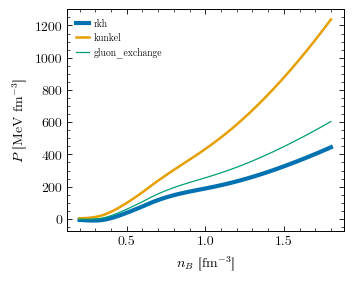

In [ ]:
fig, ax = njl_figure()
for (name, (matrix, axs)), colour, width in zip(njl_matrix.items(), OKAB_CAT,
                                                NJL_WIDTHS):
    ax.plot(axs["nB"], matrix["P"][0], color=colour, lw=width, label=name)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["P"])
ax.legend(loc="upper left", fontsize="x-small")
plt.show()

### njl — constituent masses

From the gap equation at every point, so these are solved quantities. All
three sets coincide; the widths are what makes that legible.

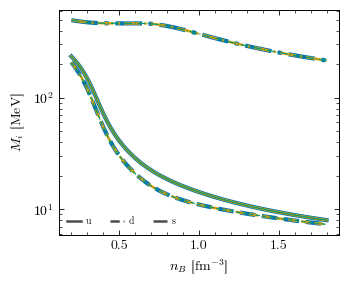

In [ ]:
fig, ax = njl_figure()
for (name, (matrix, axs)), colour, width in zip(njl_matrix.items(), OKAB_CAT,
                                                NJL_WIDTHS):
    for flavour, style in FLAVOUR_LS.items():
        ax.plot(axs["nB"], matrix[f"M_{flavour}"][0], color=colour, ls=style,
                lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(r"$M_i$ [MeV]")
ax.set_yscale("log")
log_decades(ax, axis="y")
njl_style_legend(ax, FLAVOUR_LS.items(), loc="lower left", ncol=3,
                 fontsize="x-small")
plt.show()

### njl — composition

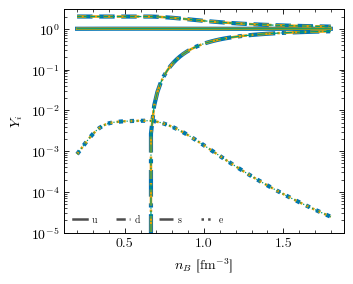

In [ ]:
fig, ax = njl_figure()
for (name, (matrix, axs)), colour, width in zip(njl_matrix.items(), OKAB_CAT,
                                                NJL_WIDTHS):
    for flavour, style in FLAVOUR_LS.items():
        ax.plot(axs["nB"], matrix[f"Y_{flavour}"][0], color=colour, ls=style,
                lw=width)
    ax.plot(axs["nB"], matrix["Y_e"][0], color=colour, ls=":", lw=width)
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel(LABELS["Y_i"])
ax.set_yscale("log")
ax.set_ylim(1e-5, 3.0)
log_decades(ax, axis="y")
njl_style_legend(ax, list(FLAVOUR_LS.items()) + [("e", ":")],
                 loc="lower left", ncol=4, fontsize="x-small")
plt.show()

### ccdm — pressure

## A parameter scan you drive

ccdm, unpaired, T = 0, beta equilibrium. **Everything selectable is in the
next cell and nowhere else**: one parameter is swept, the rest are held, and
moving to the next study is two lines. The three the notes above call for:

    SWEEP = ("B_g_quarter", (150., 170., 190., 210., 230.))   # this one
    SWEEP = ("g_s",         (3., 4., 5., 6., 8.))             # then this
    SWEEP = ("gbar_omega",  (0., 2., 4., 6., 8., 10.))        # with n_c = 3
    SWEEP = ("n_c",         (1., 3., 10., float("inf")))     # and then this
    SWEEP = ("k_omega",     (0.5, 1., 2., 4.))                # the decay's shape
    SWEEP = ("p",           (0.5, 1., 2., 3.))                # the dielectric

That last one is the dielectric exponent, `chi = (1 - phi_bar^4)^p`, and it is
the knob on HOW FAST the dilaton melts. The anomaly argument fixes the FOURTH
POWER inside the bracket, because that combination is the gluon condensate; it
says nothing about the power of the bracket, and both endpoints -- `chi = 1`
at `phi_bar = 0`, `chi = 0` at `phi_bar = 1` -- hold for every `p > 0`. So `p`
moves only the approach between them, and that is what the sweep shows: at
`n_B = 1.5` fm^-3 the solved `phi_bar` is 0.598, 0.405, 0.176, 0.074 for
`p = 0.5, 1, 2, 3`, a factor of eight, while the density where `P` crosses
zero barely moves (1.35 -> 1.40 fm^-3 from `p = 1` to `p = 3`) and the lowest
density with a deconfined solution at all goes 1.00 -> 0.80. **`B_g_quarter`
is the onset knob and `p` is the profile knob** -- the bag sweep above moves
that floor 1.00 -> 1.65 fm^-3, which `p` never does. Below 1 it changes the
character instead of the numbers: at `p = 0.5` the pressure is positive over
the whole axis, so the phase is self-bound and there is no `P = 0` crossing
to be an onset. A structural choice declared per run rather than a sampled
one, and `q <= p` binds: `q = 1` needs `p >= 1`.

`n_c` is left at the model default 1.0 fm^-3 for the bag scan, since it only
scales a vector coupling the bag scan is not varying; set it to 3.0 in
`HELD` before the `gbar_omega` sweep, as planned.

**`n_c = inf` is the constant-coupling model, exactly** — it is the
`constvector` published set. `g_omega = gbar_omega/[1 + (n_B/n_c)^2]` returns
`gbar_omega`, and the rearrangement `Sigma_R = (dg/dn_B) omega_0 n_B` carries
`n_c^2` in its denominator, so it vanishes with it. No second code path.

READ dP/dn_B ON THIS SWEEP, not only the onset — and there is a closed-form
rule for where it goes wrong. The two vector terms of `P` are the field
energy and `Sigma_R n_q`, and together

    P_vec = (n_q^2/m_omega^2) g^2 [ 1/2 - k u^k/(1 + u^k) ] ,   u = n_B/n_c

so the vector sector starts REMOVING pressure once the coupling's
logarithmic slope passes -1/2, at `u > (2k - 1)^(-1/k)` = 0.577 for the
shipped `k = 2`. Worse, `P_vec` is already falling from `u = 0.363` (the
roots of `3u^4 - 8u^2 + 1 = 0` are 0.363 and 1.592). **Keep `0.363 n_c`
above the top of the density axis** and the sector is monotonic over it: for
a table reaching 2.6 fm^-3 that is `n_c >= 7.2` fm^-3. At `n_c = 3` with
`gbar_omega = 4` it is badly violated and `P` falls from the onset, reaching
`c_s^2 = -0.59` — mechanically unstable, not soft.

`k_omega` is the exponent of that decay, and unlike the 4 inside the
dielectric bracket (which the scale anomaly fixes) it is a modelling choice.
It is a weak lever on WHERE the turnover sits — the threshold above is 1.0,
0.577, 0.585, 0.615 for `k = 1, 2, 3, 4` — and a qualitative switch at
`k = 1/2`, at or below which the slope never reaches -1/2 and the vector
sector adds pressure at every density. The price is that so gentle a decay
never saturates the vector energy, which is what the density dependence was
for. At `gbar_omega = 4`, `n_c = 3` fm^-3 the same point that is unstable at
`k = 2` is monotonic at `k = 1` and at `k = 0.5`.

A larger bag pushes the deconfinement onset up (a bigger bag costs more to
open), so the density axis has to reach well past it or the stiffest sets
come back empty. The counts printed say where each one begins.

In [ ]:
CCDM_SETS = ("baseline", "novector", "dressed", "stiff")

In [ ]:
SWEEP = ("p", (1, 2, 4, 6, 8))

HELD = dict(B_g_quarter = 165.,
            g_q=3.0,          # pinned by the specification's section 10 table
            g_s=3.0,          # flavour-symmetric choice, prior 3-8
            m_sigma=550.0,    # held throughout
            gbar_omega=2.0,   # 0-10 in the later scan
            n_c=float("inf")
            )          # 3.0 for that scan, then 1-3-10-20

SCAN_NB = np.linspace(0.3, 2.60, 41)
SCAN_FLAGS = ccdm.SpeciesFlags(csc=False)

scan_name, scan_values = SWEEP
scan = {}
print(f"=== ccdm, beta_eq_neutrinoless, T = 0, unpaired ===")
print(f"sweeping {scan_name} over {list(scan_values)}; held: {HELD}\n")
for value in scan_values:
    # The swept name is dropped from HELD rather than assumed absent from it:
    # `HELD` lists gbar_omega and n_c, so sweeping either of those would hand
    # `replace` the same keyword twice and raise before a single point is
    # solved. One dict comprehension, and every entry of the SWEEP menu works.
    held = {name: held_value for name, held_value in HELD.items()
            if name != scan_name}
    par = replace(ccdm.Parameters.default(), **held, **{scan_name: value})
    rows = ccdm_rows_from_result(ccdm.eos_table(
        par, "beta_eq_neutrinoless", SCAN_FLAGS,
        {"nB": SCAN_NB, "T": np.array([0.0])}, backend="fast"))
    label = f"{scan_name} = {value:g}"
    if not rows:
        print(f"  [{label:22s}]   0/{len(SCAN_NB)} points: no deconfined "
              f"phase on this axis")
        continue
    scan[label] = (par, *matrix_from_rows(rows))
    print(f"  [{label:22s}] {len(rows):3d}/{len(SCAN_NB)} points, onset at "
          f"n_B = {rows[0]['n_B']:.3f} fm^-3 ({rows[0]['n_B']/0.16:.2f} n_sat)")


def scan_figure(ylabel):
    fig, axes = paper_grid("1x1", mode="single", placeholder=False, aspect=1.25)
    ax = axes.ravel()[0]
    ax.set_xlabel(LABELS["nB"])
    ax.set_ylabel(ylabel)
    return fig, ax


def scan_curves():
    """(label, par, matrix, n_B, colour) for every set that solved."""
    for (label, (par, matrix, axs)), colour in zip(scan.items(), OKAB_CAT):
        yield label, par, matrix, axs["nB"], colour

=== ccdm, beta_eq_neutrinoless, T = 0, unpaired ===
sweeping p over [1, 2, 4, 6, 8]; held: {'B_g_quarter': 165.0, 'g_q': 3.0, 'g_s': 3.0, 'm_sigma': 550.0, 'gbar_omega': 2.0, 'n_c': inf}

  [p = 1                 ]  27/41 points, onset at n_B = 1.105 fm^-3 (6.91 n_sat)
  [p = 2                 ]  40/41 points, onset at n_B = 0.358 fm^-3 (2.23 n_sat)
  [p = 4                 ]  41/41 points, onset at n_B = 0.300 fm^-3 (1.88 n_sat)
  [p = 6                 ]  33/41 points, onset at n_B = 0.760 fm^-3 (4.75 n_sat)
  [p = 8                 ]  34/41 points, onset at n_B = 0.703 fm^-3 (4.39 n_sat)


### Pressure

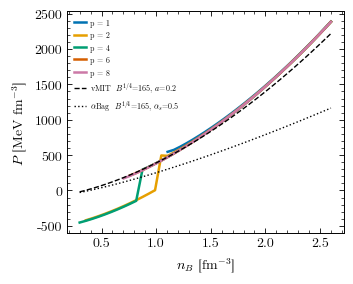

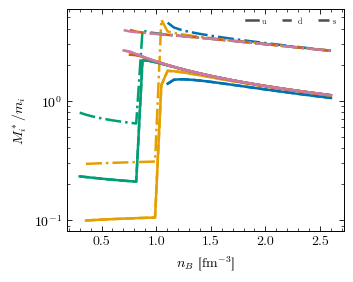

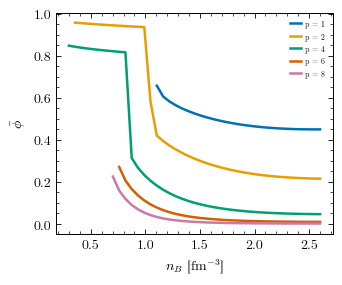

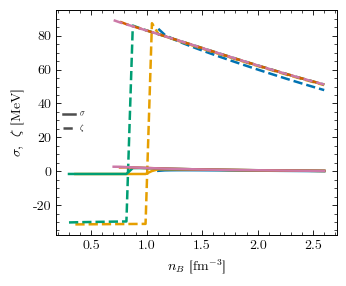

In [ ]:
# The two bag models on the same axis, at a parametrization set here rather
# than taken from `Parameters.default()`: black, so the coloured curves stay
# the CCDM scan.
BAG_SETS = {
    r"vMIT  $B^{1/4}$=165, $a$=0.2": (
        vmit, replace(vmit.Parameters.default(), B4=165.0, a=0.2),
        vmit.SpeciesFlags(), "--"),
    r"$\alpha$Bag  $B^{1/4}$=165, $\alpha_s$=0.5": (
        alphabag, replace(alphabag.Parameters.default(), B4=165.0, alpha=0.5),
        alphabag.SpeciesFlags(), ":"),
}

fig, ax = scan_figure(LABELS["P"])
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(n_B, matrix["P"][0], color=colour, label=label)
for label, (module, par, species, style) in BAG_SETS.items():
    rows = module.rows_from_result(module.eos_table(
        par, "beta_eq_neutrinoless", species,
        {"nB": SCAN_NB, "T": np.array([0.0])}))
    matrix, axs = matrix_from_rows(rows)
    ax.plot(axs["nB"], matrix["P"][0], color="k", ls=style, lw=1.0,
            label=label)
ax.legend(loc="upper left", fontsize="xx-small")
plt.show()

fig, ax = scan_figure(r"$M^*_i / m_i$")
CURRENT = {"u": "m_u", "d": "m_d", "s": "m_s"}
for label, par, matrix, n_B, colour in scan_curves():
    for flavour, style in FLAVOUR_LS.items():
        m_current = getattr(par, CURRENT[flavour])
        ax.plot(n_B, matrix[f"M_{flavour}"][0] / m_current,
                color=colour, ls=style)
ax.set_yscale("log")
log_decades(ax, axis="y")
njl_style_legend(ax, FLAVOUR_LS.items(), loc="upper right", ncol=3,
                 fontsize="xx-small")
plt.show()

fig, ax = scan_figure(r"$\bar{\phi}$")
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(n_B, matrix["phi_bar"][0], color=colour, label=label)
ax.legend(loc="upper right", fontsize="xx-small")
plt.show()

fig, ax = scan_figure(r"$\sigma$,  $\zeta$ [MeV]")
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(n_B, matrix["sigma"][0], color=colour, ls="-", label=label)
    ax.plot(n_B, matrix["zeta"][0], color=colour, ls="--")
njl_style_legend(ax, [(r"$\sigma$", "-"), (r"$\zeta$", "--")],
                 loc="center left", fontsize="xx-small")
plt.show()



## Colour superconductivity at T = 0

`csc=True` makes the three gaps unknowns, adds the pairing correction to
`Omega`, `eps`, `s` and every density, and solves `mu_3` and `mu_8` from
colour neutrality within the pattern. `eta = 1,2,3` pair `(ds)`, `(us)`,
`(ud)`, so CFL is `Delta_1 = Delta_2 ~ Delta_3` and 2SC is `Delta_3` alone
with the other two zero. Which pattern holds is enumerated and compared, not
declared: `patterns=("unpaired", "2SC", "CFL")` is the documented
restriction, an explicit statement that uSC/dSC-like states are not being
hunted here.

The pairing sector is calibrated at the shipped set — `G_D = 5e-6` MeV^-2 and
`Lambda = 600` MeV put the gap inside the 20-150 MeV window at
`mu_q ~ 450` MeV — so this cell drives `Parameters.default()` rather than the
swept `HELD` above, where the gap would move with `B_g` and mean something
else at every point.

**The condensation energy is read off `eps`, not `P`.** At fixed density the
winner is the smallest `f = eps - T s`, which at T = 0 is `eps` itself; at
fixed POTENTIAL it is the largest `P`. Both are in the model and each is
right in its own place, so the paired branch sits below the unpaired one in
energy at every density while its pressure sits BELOW at low density and
above it higher up. A `dP < 0` row is the wrong potential being read, not a
solve that went wrong.

In [ ]:
CSC_NB = np.linspace(1.0, 2.0, 11)
CSC_PAR = ccdm.Parameters.default()
CSC_PATTERNS = ("unpaired", "2SC", "CFL")

csc_rows = {}
print("=== ccdm, csc on/off, beta_eq_neutrinoless, T = 0, backend='fast' ===")
for label, csc in (("unpaired", False), ("paired", True)):
    # `patterns` restricts the pairing enumeration and is meaningful only once
    # `csc` is on; at csc=False the enumeration is `unpaired` and nothing else.
    kwargs = {"patterns": CSC_PATTERNS} if csc else {}
    start = time.perf_counter()
    csc_rows[label] = ccdm_rows_from_result(ccdm.eos_table(
        CSC_PAR, "beta_eq_neutrinoless", ccdm.SpeciesFlags(csc=csc),
        {"nB": CSC_NB, "T": np.array([0.0])}, backend="fast", **kwargs))
    print(f"  [{label:8s}] {len(csc_rows[label]):2d}/{len(CSC_NB)} points in "
          f"{time.perf_counter() - start:5.1f} s")

# The two tables are joined on density rather than laid on a common grid with
# `matrix_from_rows`: solved densities carry float noise off the requested
# axis, and that function matches exactly and raises. The key is rounded, which
# is enough because the noise is round-off and the grid spacing is 0.1 fm^-3.
unpaired = {round(row["n_B"], 6): row for row in csc_rows["unpaired"]}

print(f"\n{'n_B':>6} {'pattern':>9} {'D_1=D_2':>8} {'D_3':>8} {'mu_3':>7} "
      f"{'mu_8':>8} {'dP':>9} {'d(eps)':>9}  gapless")
for row in csc_rows["paired"]:
    plain = unpaired[round(row["n_B"], 6)]
    print(f"{row['n_B']:6.2f} {row['pattern']:>9} {row['Delta_1']:8.2f} "
          f"{row['Delta_3']:8.2f} {row['mu_3']:7.2f} {row['mu_8']:8.2f} "
          f"{row['P'] - plain['P']:9.2f} {row['eps'] - plain['eps']:9.2f}"
          f"  {row['gapless']}")

=== ccdm, csc on/off, beta_eq_neutrinoless, T = 0, backend='fast' ===
  [unpaired] 11/11 points in   0.1 s
  [paired  ] 11/11 points in   9.0 s

   n_B   pattern  D_1=D_2      D_3    mu_3     mu_8        dP    d(eps)  gapless
  1.00       2SC     0.00   143.26    0.00    -6.41    -16.00    -34.22  True
  1.10       CFL   115.54   113.12    0.51  -101.94    -38.34    -63.97  False
  1.20       CFL   117.51   115.31    0.51   -96.31    -20.64    -72.48  False
  1.30       CFL   118.86   116.85    0.51   -91.16     -3.03    -79.53  False
  1.40       CFL   119.60   117.78    0.51   -86.41     15.55    -85.19  False
  1.50       CFL   119.75   118.09    0.51   -82.00     35.56    -89.47  False
  1.60       CFL   119.30   117.80    0.51   -77.88     57.28    -92.37  False
  1.70       CFL   118.25   116.90    0.51   -74.03     80.87    -93.85  False
  1.80       CFL   116.57   115.36    0.51   -70.40    106.49    -93.88  False
  1.90       CFL   114.32   113.07    0.53   -65.87    133.76   

### The gaps and what they buy

Panel (a) is the three gaps; an open marker is a point the solver flagged
`gapless`, where the pattern's name no longer implies a fully gapped
spectrum. Panel (b) is the condensation energy at fixed density,
`eps_paired - eps_unpaired`, which is negative wherever pairing wins.

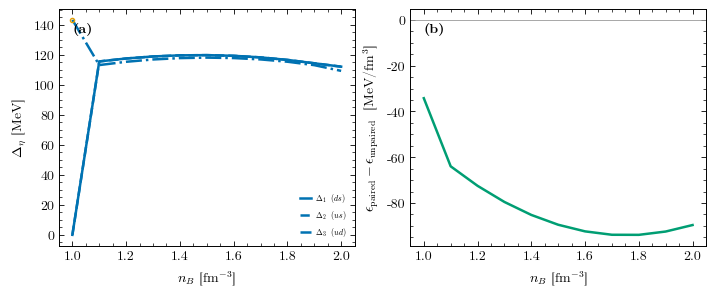

In [ ]:
n_B_csc = np.array([row["n_B"] for row in csc_rows["paired"]])
d_eps = np.array([row["eps"] - unpaired[round(row["n_B"], 6)]["eps"]
                  for row in csc_rows["paired"]])

fig, axes = paper_grid("1x2", mode="double", placeholder=False, aspect=1.25)
ax_gap, ax_cond = axes.ravel()

for key, style, label in (("Delta_1", "-",  r"$\Delta_1$  ($ds$)"),
                          ("Delta_2", "--", r"$\Delta_2$  ($us$)"),
                          ("Delta_3", "-.", r"$\Delta_3$  ($ud$)")):
    ax_gap.plot(n_B_csc, [row[key] for row in csc_rows["paired"]],
                color=OKAB_CAT[0], ls=style, label=label)
for row, n in zip(csc_rows["paired"], n_B_csc):
    if row["gapless"]:
        ax_gap.plot(n, row["Delta_3"], "o", ms=3, mfc="none",
                    color=OKAB_CAT[1])
ax_gap.set_xlabel(LABELS["nB"])
ax_gap.set_ylabel(r"$\Delta_\eta$ [MeV]")
ax_gap.legend(loc="lower right", fontsize="xx-small")
panel_label(ax_gap, "(a)")

ax_cond.axhline(0.0, color="0.6", lw=0.6)
ax_cond.plot(n_B_csc, d_eps, color=OKAB_CAT[2])
ax_cond.set_xlabel(LABELS["nB"])
ax_cond.set_ylabel(r"$\epsilon_{\rm paired}-\epsilon_{\rm unpaired}$"
                   r"  [MeV/fm$^3$]")
panel_label(ax_cond, "(b)")
plt.show()

### The same quantities against mu_B

**Against `n_B` these curves are not single branches.** At fixed density the
winner is the smallest `f = eps - T s`, and two branches coexist over a
window, so where the winner switches BOTH `P` and `mu_B` jump: at `p = 2` the
step from `n_B = 0.990` to 1.047 takes `P` from +3.9 to +494.8 MeV/fm^3 and
`mu_B` from 1713 to 1946 MeV. The tell that the sequence is not one curve is
the pair just above it, where `mu_B` FALLS from 1945.7 to 1937.8 MeV as the
density rises — `dmu_B/dn_B < 0` is impossible on a single stable branch, so
those two points belong to different ones.

`mu_B` is the variable that unfolds it. At fixed potential the branches are
ordered by `P` and the transition is where two of them CROSS, so each branch
is a continuous curve and the jump becomes a crossing. A doubling-back in
these panels is the coexistence window drawn honestly, not a solver failure.

Every point here converged: `rows_from_result` returns solved points only, so
a density the model could not reach is absent from the curve rather than
plotted. What the line between two points asserts is a different matter, and
across a branch change it asserts too much.

In [ ]:
def scan_figure_mu(ylabel):
    fig, axes = paper_grid("1x1", mode="single", placeholder=False, aspect=1.25)
    ax = axes.ravel()[0]
    ax.set_xlabel(LABELS["mu_B"])
    ax.set_ylabel(ylabel)
    return fig, ax


fig, ax = scan_figure_mu(LABELS["P"])
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(matrix["mu_B"][0], matrix["P"][0], color=colour, marker=".",
            ms=3, label=label)
ax.axhline(0.0, color="0.6", lw=0.6, zorder=0)
ax.legend(loc="upper left", fontsize="xx-small")
plt.show()

fig, ax = scan_figure_mu(r"$M^*_i / m_i$")
for label, par, matrix, n_B, colour in scan_curves():
    for flavour, style in FLAVOUR_LS.items():
        m_current = getattr(par, CURRENT[flavour])
        ax.plot(matrix["mu_B"][0], matrix[f"M_{flavour}"][0] / m_current,
                color=colour, ls=style)
ax.set_yscale("log")
log_decades(ax, axis="y")
njl_style_legend(ax, FLAVOUR_LS.items(), loc="upper right", ncol=3,
                 fontsize="xx-small")
plt.show()

fig, ax = scan_figure_mu(r"$\bar{\phi}$")
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(matrix["mu_B"][0], matrix["phi_bar"][0], color=colour, marker=".",
            ms=3, label=label)
ax.legend(loc="upper right", fontsize="xx-small")
plt.show()

fig, ax = scan_figure_mu(r"$\sigma$,  $\zeta$ [MeV]")
for label, par, matrix, n_B, colour in scan_curves():
    ax.plot(matrix["mu_B"][0], matrix["sigma"][0], color=colour, ls="-",
            label=label)
    ax.plot(matrix["mu_B"][0], matrix["zeta"][0], color=colour, ls="--")
njl_style_legend(ax, [(r"$\sigma$", "-"), (r"$\zeta$", "--")],
                 loc="center left", fontsize="xx-small")
plt.show()